In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 한글 폰트
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [4]:
df = pd.read_csv("/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/21-25전국_부산_폐업수.csv")
df.head()

,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자
0,2025,전국,전국,975681,85270,890411,483210,313861,93340
1,2025,부산전체,부산,56651,4177,52474,28514,18942,5018
2,2025,부산구군,강서구,3850,408,3442,2310,834,298
3,2025,부산구군,금정구,3365,244,3121,1706,1127,288
4,2025,부산구군,기장군,3200,268,2932,1537,1079,316


In [5]:
busan = df[df['지역구분'] == '부산구군'].copy()

busan.head()

,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자
2,2025,부산구군,강서구,3850,408,3442,2310,834,298
3,2025,부산구군,금정구,3365,244,3121,1706,1127,288
4,2025,부산구군,기장군,3200,268,2932,1537,1079,316
5,2025,부산구군,남구,3676,326,3350,1718,1279,353
6,2025,부산구군,동구,2277,196,2081,1263,680,138


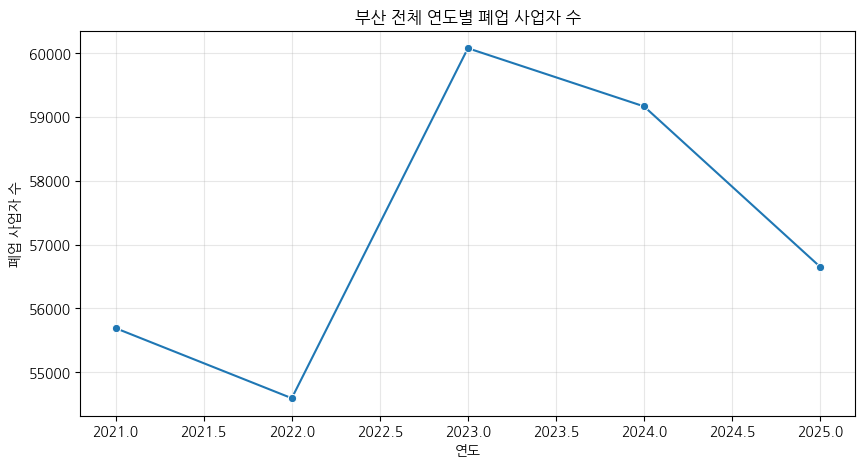

In [6]:
# 부산 전 지역의 폐업수가 증가했는지 확인
busan_total = df[df['지역구분'] == '부산전체'].copy()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=busan_total,
    x='연도',
    y='폐업사업자_총계',
    marker='o'
)

plt.title('부산 전체 연도별 폐업 사업자 수')
plt.xlabel('연도')
plt.ylabel('폐업 사업자 수')
plt.grid(alpha=0.3)

plt.show()

In [8]:
# 전년 대비 폐업 증감률 YoY
busan_total = busan_total.sort_values('연도')

busan_total['폐업_YoY'] = (
    busan_total['폐업사업자_총계']
    .pct_change() * 100
)

busan_total[['연도', '폐업사업자_총계', '폐업_YoY']]

,연도,폐업사업자_총계,폐업_YoY
73,2021,55691,NaN
55,2022,54594,-1.969798
37,2023,60075,10.039565
19,2024,59164,-1.516438
1,2025,56651,-4.247515


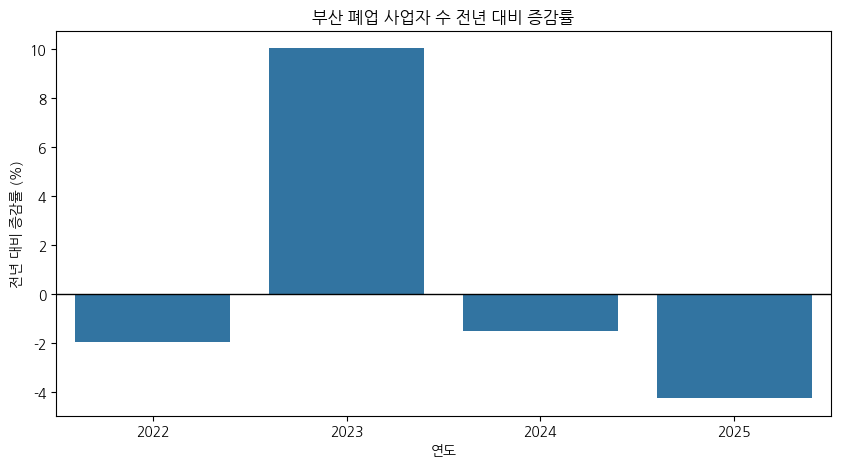

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=busan_total.dropna(),
    x='연도',
    y='폐업_YoY'
)

plt.axhline(0, color='black', linewidth=1)

plt.title('부산 폐업 사업자 수 전년 대비 증감률')
plt.xlabel('연도')
plt.ylabel('전년 대비 증감률 (%)')

plt.show()

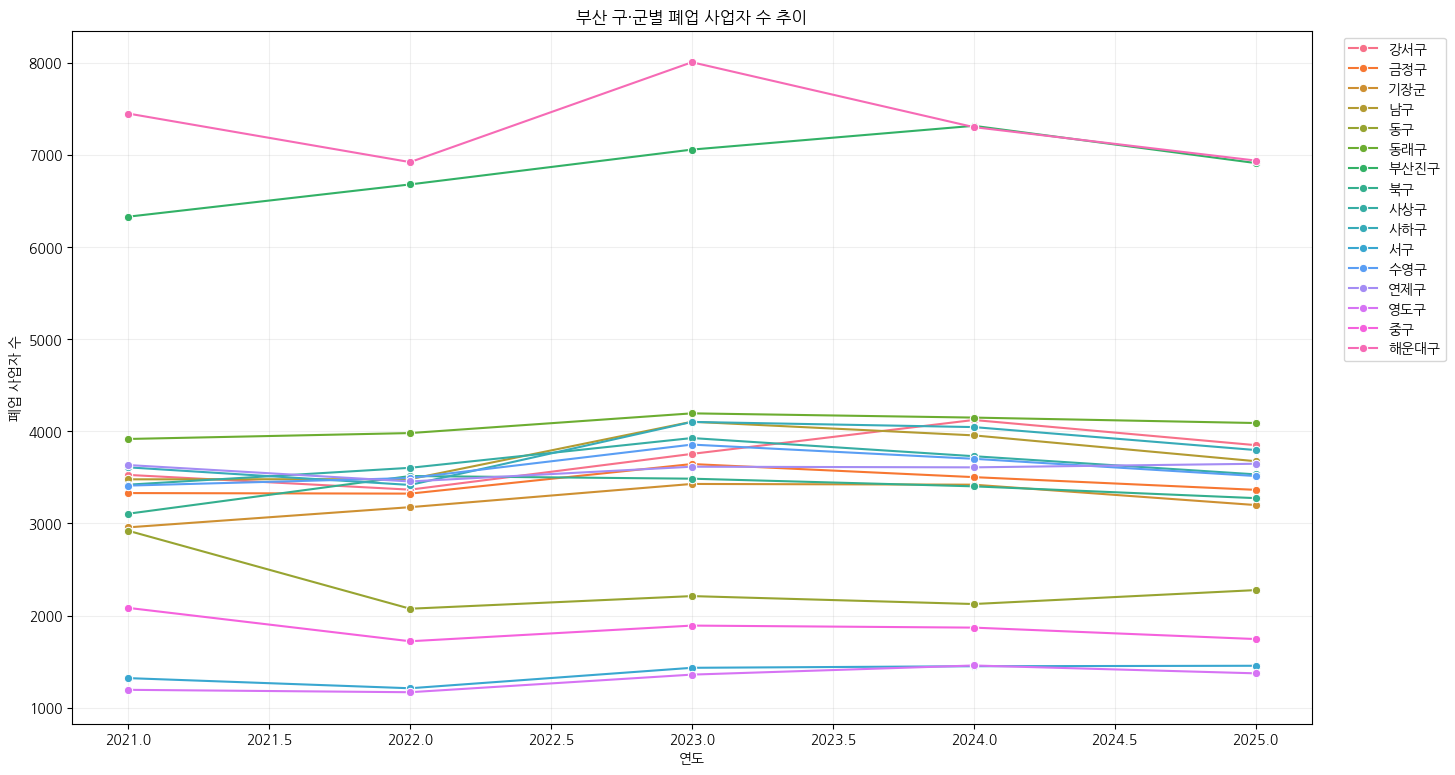

In [10]:
# 구 / 군 별 폐업 추이
plt.figure(figsize=(16, 9))

sns.lineplot(
    data=busan,
    x='연도',
    y='폐업사업자_총계',
    hue='지역명',
    marker='o'
)

plt.title('부산 구·군별 폐업 사업자 수 추이')
plt.xlabel('연도')
plt.ylabel('폐업 사업자 수')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(alpha=0.2)
plt.show()

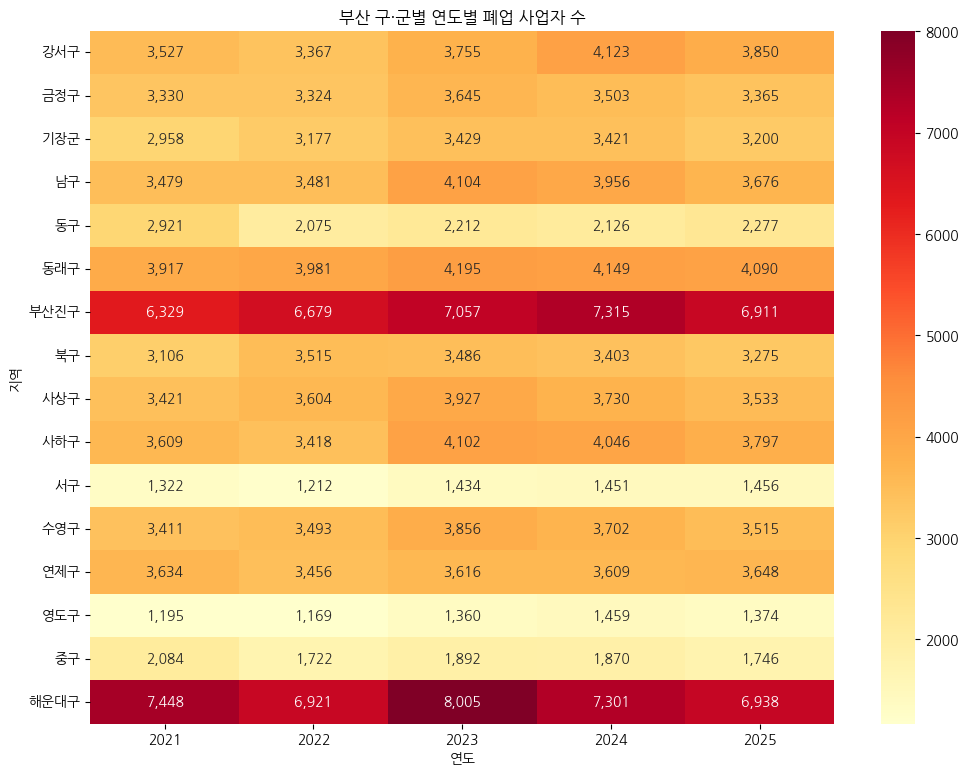

In [11]:
#지역 x 연도별 폐업 히트맵
pivot = busan.pivot(
    index='지역명',
    columns='연도',
    values='폐업사업자_총계'
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    pivot,
    annot=True,
    fmt=',',
    cmap='YlOrRd'
)

plt.title('부산 구·군별 연도별 폐업 사업자 수')
plt.xlabel('연도')
plt.ylabel('지역')

plt.show()

In [13]:
busan = busan.sort_values(['지역명', '연도'])

busan['폐업_YoY'] = (
    busan.groupby('지역명')['폐업사업자_총계']
    .pct_change() * 100
)

busan[
    ['연도', '지역명', '폐업사업자_총계', '폐업_YoY']
].head(20)

,연도,지역명,폐업사업자_총계,폐업_YoY
74,2021,강서구,3527,NaN
56,2022,강서구,3367,-4.536433
38,2023,강서구,3755,11.523612
20,2024,강서구,4123,9.800266
2,2025,강서구,3850,-6.621392
75,2021,금정구,3330,NaN
57,2022,금정구,3324,-0.180180
39,2023,금정구,3645,9.657040
21,2024,금정구,3503,-3.895748
3,2025,금정구,3365,-3.939480


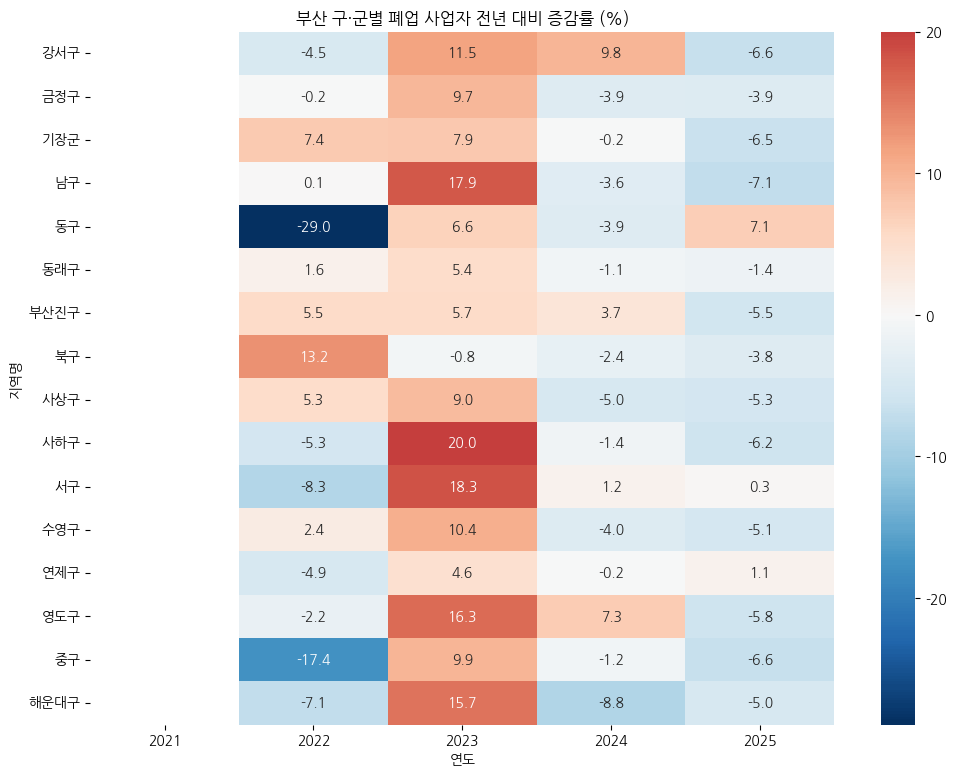

In [14]:
yoy_pivot = busan.pivot(
    index='지역명',
    columns='연도',
    values='폐업_YoY'
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    yoy_pivot,
    annot=True,
    fmt='.1f',
    center=0,
    cmap='RdBu_r'
)

plt.title('부산 구·군별 폐업 사업자 전년 대비 증감률 (%)')

plt.show()

In [15]:
busan['폐업지수_2021_100'] = (
    busan.groupby('지역명')['폐업사업자_총계']
    .transform(lambda x: x / x.iloc[0] * 100)
)

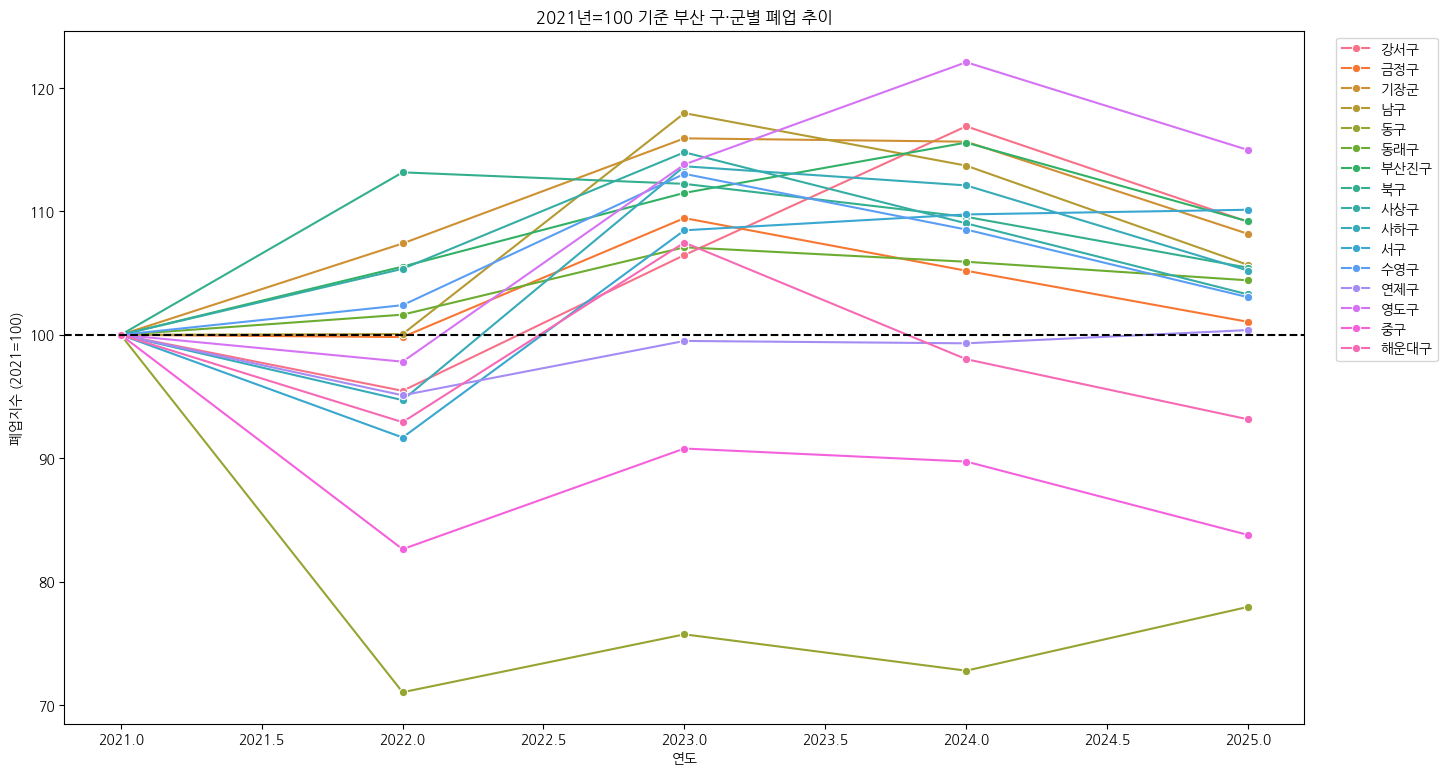

In [19]:
plt.figure(figsize=(16, 9))

sns.lineplot(
    data=busan,
    x='연도',
    y='폐업지수_2021_100',
    hue='지역명',
    marker='o'
)

plt.axhline(100, linestyle='--', color='black')

plt.title('2021년=100 기준 부산 구·군별 폐업 추이')
plt.ylabel('폐업지수 (2021=100)')
plt.xlabel('연도')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

In [20]:
busan

,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자,폐업_YoY,폐업지수_2021_100,개인사업자_폐업비중,간이사업자_폐업비중
74,2021,부산구군,강서구,3527,339,3188,2206,658,324,NaN,100.000000,90.388432,18.656082
56,2022,부산구군,강서구,3367,351,3016,1991,755,270,-4.536433,95.463567,89.575290,22.423522
38,2023,부산구군,강서구,3755,353,3402,2216,883,303,11.523612,106.464417,90.599201,23.515313
20,2024,부산구군,강서구,4123,414,3709,2374,1032,303,9.800266,116.898214,89.958768,25.030318
2,2025,부산구군,강서구,3850,408,3442,2310,834,298,-6.621392,109.157925,89.402597,21.662338
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,2021,부산구군,해운대구,7448,638,6810,4218,1776,816,NaN,100.000000,91.433942,23.845328
71,2022,부산구군,해운대구,6921,608,6313,3485,2072,756,-7.075725,92.924275,91.215142,29.937870
53,2023,부산구군,해운대구,8005,664,7341,4038,2579,724,15.662477,107.478518,91.705184,32.217364
35,2024,부산구군,해운대구,7301,547,6754,3704,2312,738,-8.794503,98.026316,92.507876,31.666895


In [21]:
from scipy.stats import pearsonr, spearmanr

In [22]:
폐업 = pd.read_csv("/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/21-25전국_부산_폐업수.csv")
신설 = pd.read_csv("/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/부산_월별_구군별_신설법인_202401-202601.csv")

display(폐업.head())
display(신설.head())

,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자
0,2025,전국,전국,975681,85270,890411,483210,313861,93340
1,2025,부산전체,부산,56651,4177,52474,28514,18942,5018
2,2025,부산구군,강서구,3850,408,3442,2310,834,298
3,2025,부산구군,금정구,3365,244,3121,1706,1127,288
4,2025,부산구군,기장군,3200,268,2932,1537,1079,316


,연월,행정구,신설법인수,부산전체신설법인수,부산전체대비비중_pct,원문비중_pct,월내순위,전월대비증감수,전월대비증감률_pct,전년동월대비증감수,전년동월대비증감률_pct,3개월이동평균,6개월이동평균,데이터상태,수치생성방식,출처파일,검증_주의
0,202401,강서구,69.0,453,15.23,15.2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,원문그래프직접,원문 구군별 그래프 개체수 직접 판독,2._2024년_1월중_부산지역_신설법인_현황_조사_보고서_대외용.pdf,NaN
1,202401,해운대구,66.0,453,14.57,14.6,2.0,NaN,NaN,NaN,NaN,NaN,NaN,원문그래프직접,원문 구군별 그래프 개체수 직접 판독,2._2024년_1월중_부산지역_신설법인_현황_조사_보고서_대외용.pdf,NaN
2,202401,부산진구,42.0,453,9.27,9.3,3.0,NaN,NaN,NaN,NaN,NaN,NaN,원문그래프직접,원문 구군별 그래프 개체수 직접 판독,2._2024년_1월중_부산지역_신설법인_현황_조사_보고서_대외용.pdf,NaN
3,202401,기장군,35.0,453,7.73,7.7,4.0,NaN,NaN,NaN,NaN,NaN,NaN,원문그래프직접,원문 구군별 그래프 개체수 직접 판독,2._2024년_1월중_부산지역_신설법인_현황_조사_보고서_대외용.pdf,NaN
4,202401,남구,28.0,453,6.18,6.2,5.0,NaN,NaN,NaN,NaN,NaN,NaN,원문그래프직접,원문 구군별 그래프 개체수 직접 판독,2._2024년_1월중_부산지역_신설법인_현황_조사_보고서_대외용.pdf,NaN


In [23]:
신설['연도'] = 신설['연월'] // 100
신설['월'] = 신설['연월'] % 100

신설[['연월', '연도', '월', '행정구', '신설법인수']].head()

,연월,연도,월,행정구,신설법인수
0,202401,2024,1,강서구,69.0
1,202401,2024,1,해운대구,66.0
2,202401,2024,1,부산진구,42.0
3,202401,2024,1,기장군,35.0
4,202401,2024,1,남구,28.0


In [26]:
신설_비교 = 신설[
    (신설['연도'].isin([2024, 2025])) &
    (신설['월'] <= 11)
].copy()

신설_연간 = (
    신설_비교
    .groupby(['연도', '행정구'], as_index=False)
    ['신설법인수']
    .sum()
)

신설_연간.tail()

,연도,행정구,신설법인수
27,2025,수영구,405.0
28,2025,연제구,215.0
29,2025,영도구,61.0
30,2025,중구,145.0
31,2025,해운대구,552.0


In [25]:
폐업_구군 = 폐업[
    (폐업['지역구분'] == '부산구군') &
    (폐업['연도'].isin([2024, 2025]))
].copy()

폐업_구군.head()

,연도,지역구분,지역명,폐업사업자_총계,법인,개인사업자,일반사업자,간이사업자,면세사업자
2,2025,부산구군,강서구,3850,408,3442,2310,834,298
3,2025,부산구군,금정구,3365,244,3121,1706,1127,288
4,2025,부산구군,기장군,3200,268,2932,1537,1079,316
5,2025,부산구군,남구,3676,326,3350,1718,1279,353
6,2025,부산구군,동구,2277,196,2081,1263,680,138


In [27]:
분석 = pd.merge(
    신설_연간,
    폐업_구군,
    left_on=['연도', '행정구'],
    right_on=['연도', '지역명'],
    how='inner'
)

분석 = 분석[
    [
        '연도',
        '행정구',
        '신설법인수',
        '법인',
        '폐업사업자_총계',
        '개인사업자'
    ]
]

분석 = 분석.rename(columns={
    '법인': '폐업법인수',
    '폐업사업자_총계': '총폐업수'
})

분석.head()

,연도,행정구,신설법인수,폐업법인수,총폐업수,개인사업자
0,2024,강서구,479.0,414,4123,3709
1,2024,금정구,199.0,209,3503,3294
2,2024,기장군,239.0,276,3421,3145
3,2024,남구,281.0,249,3956,3707
4,2024,동구,207.0,218,2126,1908


In [28]:
for year in [2024, 2025]:

    temp = 분석[분석['연도'] == year]

    r, p = pearsonr(
        temp['신설법인수'],
        temp['폐업법인수']
    )

    print(f'{year}년')
    print(f'Pearson r = {r:.3f}')
    print(f'p-value = {p:.4f}')
    print()

2024년
Pearson r = 0.942
p-value = 0.0000

2025년
Pearson r = 0.865
p-value = 0.0000



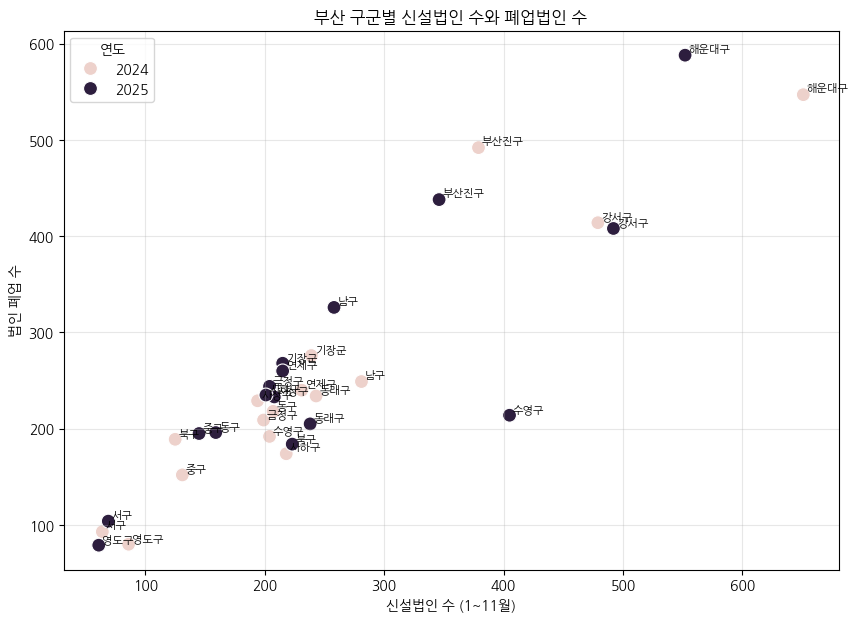

In [29]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=분석,
    x='신설법인수',
    y='폐업법인수',
    hue='연도',
    s=100
)

for _, row in 분석.iterrows():
    plt.text(
        row['신설법인수'] + 3,
        row['폐업법인수'] + 3,
        row['행정구'],
        fontsize=8
    )

plt.title('부산 구군별 신설법인 수와 폐업법인 수')
plt.xlabel('신설법인 수 (1~11월)')
plt.ylabel('법인 폐업 수')
plt.grid(alpha=0.3)

plt.show()

In [30]:
신설_growth = 분석.pivot(
    index='행정구',
    columns='연도',
    values='신설법인수'
)

신설_growth.columns = [
    '신설법인_2024',
    '신설법인_2025'
]


폐업_growth = 분석.pivot(
    index='행정구',
    columns='연도',
    values='폐업법인수'
)

폐업_growth.columns = [
    '폐업법인_2024',
    '폐업법인_2025'
]


성장분석 = pd.concat(
    [신설_growth, 폐업_growth],
    axis=1
).reset_index()

In [31]:
성장분석['신설증감률'] = (
    성장분석['신설법인_2025']
    / 성장분석['신설법인_2024']
    - 1
) * 100


성장분석['폐업증감률'] = (
    성장분석['폐업법인_2025']
    / 성장분석['폐업법인_2024']
    - 1
) * 100

성장분석.round(2)

,행정구,신설법인_2024,신설법인_2025,폐업법인_2024,폐업법인_2025,신설증감률,폐업증감률
0,강서구,479.0,492.0,414,408,2.71,-1.45
1,금정구,199.0,204.0,209,244,2.51,16.75
2,기장군,239.0,215.0,276,268,-10.04,-2.90
3,남구,281.0,258.0,249,326,-8.19,30.92
4,동구,207.0,159.0,218,196,-23.19,-10.09
5,동래구,243.0,238.0,234,205,-2.06,-12.39
6,부산진구,379.0,346.0,492,438,-8.71,-10.98
7,북구,125.0,223.0,189,184,78.40,-2.65
8,사상구,194.0,208.0,229,233,7.22,1.75
9,사하구,218.0,201.0,174,235,-7.80,35.06


In [32]:
r, p = pearsonr(
    성장분석['신설증감률'],
    성장분석['폐업증감률']
)

rho, sp = spearmanr(
    성장분석['신설증감률'],
    성장분석['폐업증감률']
)

print('Pearson')
print(f'r = {r:.3f}')
print(f'p = {p:.4f}')

print()

print('Spearman')
print(f'rho = {rho:.3f}')
print(f'p = {sp:.4f}')

Pearson
r = 0.056
p = 0.8375

Spearman
rho = 0.282
p = 0.2893


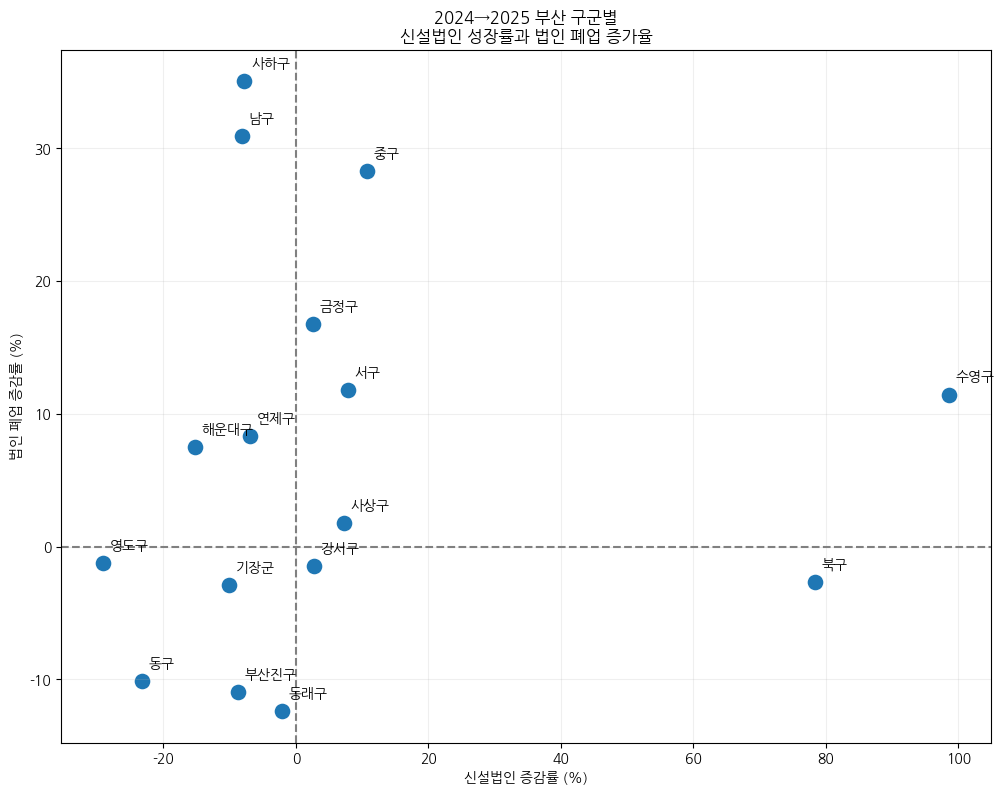

In [33]:
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=성장분석,
    x='신설증감률',
    y='폐업증감률',
    s=150
)

# 기준선
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

for _, row in 성장분석.iterrows():

    plt.text(
        row['신설증감률'] + 1,
        row['폐업증감률'] + 1,
        row['행정구'],
        fontsize=10
    )

plt.xlabel('신설법인 증감률 (%)')
plt.ylabel('법인 폐업 증감률 (%)')

plt.title(
    '2024→2025 부산 구군별\n'
    '신설법인 성장률과 법인 폐업 증가율'
)

plt.grid(alpha=0.2)

plt.show()